In [2]:
import os
import pypsa
import pandas as pd
pd.options.mode.string_storage = "python"
import matplotlib.pyplot as plt

E0000 00:00:1777451066.833770 31644124 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1777451066.834888 31644124 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1777451066.834897 31644124 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1777451066.834899 31644124 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1777451066.834902 31644124 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.


## Assumptions and References for Task 4
The Data for task 4 is fetched from the ENTSO E Transparancy Platform 

### The hydro reservoir constraint

 **hydro reservoir** generation (PSR = **B12**) treated hydro reservoir as a **dispatchable generator**. Model inflows or storage is not modeled explicitly. The **total annual energy** is constrained

---

#### Mathematical formulation

hydro reservoir generator \( g \):

$$
\sum_{t \in T} p_{g,t} \cdot \Delta t \;\le\; E^{\text{hist}}_g
$$

where:

- \(p_{g,t} \) = dispatched power \([\text{MW}]\)
- \( \Delta t \) = snapshot duration (1 h)
- \( E^{\text{hist}}_g \) = historical annual energy from ENTSO‑E \([\text{MWh}]\)

This mimics **seasonal storage flexibility**  
This is **explicitly allowed** in *Assignment 1*

### Coal Costs for Germany
Source: — PyPSA‑Eur - Brown et al. (2018)

Brown, T., Hörsch, J., & Schlachtberger, D. (2018).
PyPSA: Python for Power System Analysis.
Journal of Open Research Software, 6(1).

Used assumptions:

Coal efficiency ≈ 0.38–0.42
CO₂ intensity ≈ 0.34 t/MWhₜₕ
Fuel prices in the 10–20 €/MWhₜₕ range

Source 2: IEA — Projected Costs of Generating Electricity

International Energy Agency (IEA).
Projected Costs of Generating Electricity.

### Data refining

In [ ]:
    PSR_MAP = {
        "wind_on":      ["B19"],
        "wind_off":     ["B18"],
        "solar":        ["B16"],
        "hydro_ror":    ["B11"],
        "hydro_res":    ["B12"],
        "coal":         ["B02", "B03", "B05"],
        "gas":          ["B04"],
    }

    def pivot_generation(zone):
        # Read raw ENTSO-E generation data
        df = pd.read_csv(
            f"data/raw/generation/gen_{zone}_2025.csv",
            parse_dates=["time_utc"]
        )

        tech_series = []

        for tech, psr_list in PSR_MAP.items():
            s = (
                df[df["psr_type"].isin(psr_list)]
                .groupby("time_utc")["generation_MW"]
                .sum()
                .rename(tech)
            )
            tech_series.append(s)

        # Combine into one DataFrame
        gen_pivot = pd.concat(tech_series, axis=1, sort=False).fillna(0.0)

        return gen_pivot


    def pivot_load(zone):
        df = pd.read_csv(
            f"data/raw/load/load_{zone}_2025.csv",
            parse_dates=["time_utc"]
        )

        load = (
            df.set_index("time_utc")["load_MW"]
            .rename("load")
        )

        return load

    ### Calculating the p_max_pu for renewables

    CF_TARGET = {
        "solar": 0.11,
        "wind_on": 0.25,
        "wind_off": 0.44,
        # optional
        "hydro_ror": 0.45,  # reasonable average, document if used
    }

    def compute_p_max_pu(gen, tech):
        """
        Parameters
        ----------
        gen : pd.DataFrame
            Pivoted generation data [MW]
        tech : str
            Column name (e.g. 'wind_on', 'wind_off', 'solar')
        Returns
        -------
        pd.Series
            Hourly p_max_pu profile
        """

        generation = gen[tech]

        # Step 1: normalise by annual maximum
        p_raw = generation / generation.max()

        # Step 2: scale to target capacity factor
        p_max_pu = p_raw / p_raw.mean() * CF_TARGET[tech]

        # Safety: enforce bounds
        p_max_pu = p_max_pu.clip(lower=0.0)

        return p_max_pu


    # helper function to ensure proper formating

    def align_to_snapshots(series, network):
        s = series.copy()

        # Remove timezone if present
        if s.index.tz is not None:
            s.index = s.index.tz_localize(None)

        # 🔧 CRITICAL FIX: remove duplicate timestamps
        if not s.index.is_unique:
            s = s.groupby(s.index).sum()

        # Align to network snapshots
        s = s.reindex(network.snapshots)

        # Fill missing values
        s = s.fillna(0.0)

        return s


    ### Calculating Hydro availability

    gen_NO2 = pivot_generation("NO2")

    # remove timezone if needed
    gen_NO2.index = gen_NO2.index.tz_localize(None)

    # Annual hydro reservoir energy [MWh]
    E_hydro_NO2 = gen_NO2["hydro_res"].sum()

    def hydro_energy_constraint_NO2(n, snapshots):
        model = n.model

        # Dispatch variable for NO2 hydro
        p = model.variables["Generator-p"].loc[
            dict(name="hydro_res_NO2")
        ]   

        # Snapshot weights (1 h each in your case)
        weights = n.snapshot_weightings.generators

        # Annual energy constraint
        model.add_constraints(
            (p * weights).sum(dim="snapshot") <= E_hydro_NO2,
            name="hydro_energy_limit_NO2",
        )

    ## Cost calculations

    costs = pd.read_csv("Data/costs_PyPSA.csv")

    # Keep only 2030
    costs = costs[costs["year"] == 2030].copy()
    costs["value"] = pd.to_numeric(costs["value"], errors="coerce")
    costs = costs.set_index(["technology", "parameter"])


    # Shared costs for all tasks
    def get_cost(tech, param):
        return float(costs.loc[(tech, param), "value"])

    # Solar
    solar_capex = get_cost("solar", "investment") * 1000  # €/MW
    solar_lifetime = get_cost("solar", "lifetime")
    solar_fom_percent = get_cost("solar", "FOM")

    solar_fom = solar_fom_percent / 100 * solar_capex
    solar_marginal_cost = 0

    # Onshore wind
    onshore_capex = get_cost("onwind", "investment") * 1000
    onshore_lifetime = get_cost("onwind", "lifetime")
    onshore_fom = get_cost("onwind", "FOM") / 100 * onshore_capex
    onshore_marginal_cost = 0


    # Offshore wind
    offshore_capex = get_cost("offwind", "investment") * 1000
    offshore_lifetime = get_cost("offwind", "lifetime")
    offshore_fom = get_cost("offwind", "FOM") / 100 * offshore_capex
    offshore_marginal_cost = 0

    # Hydro
    hydro_capex = get_cost("hydro", "investment") * 1000
    hydro_lifetime = get_cost("hydro", "lifetime")
    hydro_fom = get_cost("hydro", "FOM") / 100 * hydro_capex
    hydro_marginal_cost = 0


    # Gas
    ocgt_capex = get_cost("OCGT", "investment") * 1000
    ocgt_lifetime = get_cost("OCGT", "lifetime")
    ocgt_fom = get_cost("OCGT", "FOM") / 100 * ocgt_capex
    ocgt_efficiency = get_cost("OCGT", "efficiency")
    ocgt_vom = get_cost("OCGT", "VOM")

    # Coal
    coal_capex = 1500 * 1000
    coal_lifetime = 40
    coal_fom = 3 / 100 * coal_capex
    coal_efficiency = 0.38
    coal_vom = 3


    # Battery - Used from task C
    battery_duration = 4.0 # Assumption: Maximum state of charge capacity in terms of hours at full output power capacity

    battery_inverter_efficiency_store = get_cost("battery inverter","efficiency") # Efficiency of storage on the way into the storage
    battery_inverter_efficiency_dispatch = get_cost("battery inverter","efficiency") # Efficiency of storage on the way out of the storage
    battery_inverter_capex = get_cost("battery inverter","investment") * 1000
    battery_inverter_fom = get_cost("battery inverter","FOM") / 100 * battery_inverter_capex
    battery_inverter_lifetime = get_cost("battery inverter","lifetime")

    battery_storage_capex = get_cost("battery storage","investment") * 1000
    battery_storage_lifetime = get_cost("battery storage","lifetime")

    battery_marginal_cost = 0.0


    # Assumptions for fuel and CO2
    gas_price = 40.0          # €/MWh_th
    co2_price = 80.0          # €/tCO2
    co2_intensity = 0.202     # tCO2/MWh_th

    ocgt_marginal_cost = (
        gas_price / ocgt_efficiency
        + co2_price * co2_intensity / ocgt_efficiency
        + ocgt_vom
    )

    # Assumptions for coal fuel and CO2
    coal_price = 15.0         # €/MWh_th
    coal_co2_intensity = 0.34 # tCO2/MWh_th

    coal_marginal_cost = (
        coal_price / coal_efficiency
        + co2_price * coal_co2_intensity / coal_efficiency
        + coal_vom
    )

    # Annulaize the costs
    def annuity(r, n):
        return r / (1 - (1 + r) ** (-n))

    def annualize_capex(capex, lifetime, fom=0, discount_rate=0.07):
        return capex * annuity(discount_rate, lifetime) + fom

    solar_annualized_cost = annualize_capex(solar_capex, solar_lifetime, solar_fom)
    hydro_annualized_cost = annualize_capex(hydro_capex, hydro_lifetime, hydro_fom)
    onshore_annualized_cost = annualize_capex(onshore_capex, onshore_lifetime, onshore_fom)
    offshore_annualized_cost = annualize_capex(offshore_capex, offshore_lifetime, offshore_fom)
    ocgt_annualized_cost = annualize_capex(ocgt_capex, ocgt_lifetime, ocgt_fom)
    battery_inverter_annualized_cost = annualize_capex(battery_inverter_capex, battery_inverter_lifetime, battery_inverter_fom)
    battery_storage_annualized_cost = annualize_capex(battery_storage_capex, battery_storage_lifetime)
    battery_annualized_cost = battery_inverter_annualized_cost +battery_storage_annualized_cost
    coal_annualized_cost = annualize_capex(coal_capex, coal_lifetime, coal_fom)

    print("Marginal costs:")
    print("Solar:", solar_marginal_cost)
    print("Onshore wind:", onshore_marginal_cost)
    print("Offshore wind:", offshore_marginal_cost)
    print("OCGT:", ocgt_marginal_cost)
    print("Battery:", battery_marginal_cost)
    print("--------------------------------------------------------------------")
    print("Annualized costs:")
    print("solar_annualized_cost:", solar_annualized_cost)
    print("onshore_annualized_cost:", onshore_annualized_cost)
    print("offshore_annualized_cost:", offshore_annualized_cost)
    print("ocgt_annualized_cost:", ocgt_annualized_cost)
    print("battery_inverter_annualized_cost:", battery_inverter_annualized_cost)
    print("battery_storage_annualized_cost:", battery_storage_annualized_cost)
    print("battery_annualized_cost:", battery_annualized_cost)
    print("Coal:", coal_marginal_cost)
    print("coal_annualized_cost:", coal_annualized_cost)




Marginal costs:
Solar: 0
Onshore wind: 0
Offshore wind: 0
OCGT: 147.0
Battery: 0.0
--------------------------------------------------------------------
Annualized costs:
solar_annualized_cost: 76486.31233239936
onshore_annualized_cost: 136428.03241482674
offshore_annualized_cost: 295041.146434988
ocgt_annualized_cost: 47234.561404444474
battery_inverter_annualized_cost: 51125.49248047808
battery_storage_annualized_cost: 21080.567942593243
battery_annualized_cost: 72206.06042307132
Coal: 114.05263157894737
coal_annualized_cost: 157513.70831041547


## Testing

In [61]:
def mean_capacity_factors(gen):
    results = {}

    for tech in ["solar", "wind_on", "wind_off", "hydro_ror"]:
        if tech in gen.columns:
            p_max_pu = compute_p_max_pu(gen, tech)
            results[tech] = p_max_pu.mean()

    return pd.Series(results, name="mean_capacity_factor")


# Check all countries
for zone in ["DK1", "DK2", "NO2", "DE"]:
    gen = pivot_generation(zone)
    print(f"\n{zone}")
    print(mean_capacity_factors(gen))

# Save last result if needed
mean_cfs = mean_capacity_factors(gen)

print("\nLast country checked:")
print(mean_cfs)


DK1
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64

DK2
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror     NaN
Name: mean_capacity_factor, dtype: float64

NO2
solar         NaN
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64

DE
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64

Last country checked:
solar        0.11
wind_on      0.25
wind_off     0.44
hydro_ror    0.45
Name: mean_capacity_factor, dtype: float64


### Creating the Model

In [67]:
zones = ["DK1", "DK2", "NO2", "DE"]

multi_n = pypsa.Network()

# --------------------
# Set snapshots ONCE
# --------------------
load_ref = pivot_load("DK1")

if load_ref.index.tz is not None:
    load_ref.index = load_ref.index.tz_localize(None)

multi_n.set_snapshots(load_ref.index)


# --------------------
# Add carriers
# --------------------
for carrier in ["AC", "onwind", "offwind", "solar", "gas", "coal", "hydro", "battery"]:
    multi_n.add("Carrier", carrier)


# --------------------
# Loop over zones
# --------------------
for zone in zones:

    bus = f"bus_{zone}"

    multi_n.add("Bus", name=bus, carrier="AC")

    # ---- Load ----
    load = pivot_load(zone)
    load = align_to_snapshots(load, multi_n)

    multi_n.add(
        "Load",
        name=f"load_{zone}",
        bus=bus,
        p_set=load,
    )

    # ---- Generation data ----
    gen = pivot_generation(zone)

    if gen.index.tz is not None:
        gen.index = gen.index.tz_localize(None)

    print(zone, gen.columns.tolist())

    # Co-optimise generation capacities in all regions
    extendable = True

    # --------------------
    # Wind onshore
    # --------------------
    if "wind_on" in gen.columns:
        existing_capacity = gen["wind_on"].max()

        multi_n.add(
            "Generator",
            name=f"wind_on_{zone}",
            bus=bus,
            carrier="onwind",
            p_nom_extendable=extendable,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            p_max_pu=align_to_snapshots(compute_p_max_pu(gen, "wind_on"), multi_n),
            capital_cost=onshore_annualized_cost*1.5,
            marginal_cost=0.0,
        )

    # --------------------
    # Wind offshore
    # --------------------
    if "wind_off" in gen.columns:
        existing_capacity = gen["wind_off"].max()

        multi_n.add(
            "Generator",
            name=f"wind_off_{zone}",
            bus=bus,
            carrier="offwind",
            p_nom_extendable=extendable,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            p_max_pu=align_to_snapshots(compute_p_max_pu(gen, "wind_off"), multi_n),
            capital_cost=offshore_annualized_cost,
            marginal_cost=0.0,
        )

    # --------------------
    # Solar
    # --------------------
    if "solar" in gen.columns:
        existing_capacity = gen["solar"].max()

        multi_n.add(
            "Generator",
            name=f"solar_{zone}",
            bus=bus,
            carrier="solar",
            p_nom_extendable=extendable,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            p_max_pu=align_to_snapshots(compute_p_max_pu(gen, "solar"), multi_n),
            capital_cost=solar_annualized_cost,
            marginal_cost=0.0,
        )

    # --------------------
    # Gas / OCGT
    # --------------------
    existing_capacity = gen["gas"].max() if "gas" in gen.columns else 0.0

    multi_n.add(
        "Generator",
        name=f"gas_{zone}",
        bus=bus,
        carrier="gas",
        p_nom_extendable=True,
        p_nom=existing_capacity,
        p_nom_min=existing_capacity,
        capital_cost=ocgt_annualized_cost,
        marginal_cost=ocgt_marginal_cost,
    )

    # --------------------
    # Battery storage
    # --------------------
    multi_n.add(
        "StorageUnit",
        name=f"battery_{zone}",
        bus=bus,
        carrier="battery",
        p_nom_extendable=True,
        max_hours=battery_duration,
        efficiency_store=battery_inverter_efficiency_store,
        efficiency_dispatch=battery_inverter_efficiency_dispatch,
        capital_cost=float(battery_annualized_cost),
        marginal_cost=float(battery_marginal_cost),
        cyclic_state_of_charge=True,
    )

    # --------------------
    # Coal only in Germany
    # --------------------
    if zone == "DE" and "coal" in gen.columns:
        existing_capacity = gen["coal"].max()

        multi_n.add(
            "Generator",
            name="coal_DE",
            bus=bus,
            carrier="coal",
            p_nom_extendable=True,
            p_nom=existing_capacity,
            p_nom_min=existing_capacity,
            capital_cost=coal_annualized_cost,
            marginal_cost=coal_marginal_cost,
        )

    # --------------------
    # Hydro reservoir only in NO2
    # Fixed existing hydro capacity
    # --------------------
    if zone == "NO2":
        if "hydro_res" in gen.columns:
            existing_capacity = gen["hydro_res"].max()

            multi_n.add(
                "Generator",
                name="hydro_res_NO2",
                bus=bus,
                carrier="hydro",
                p_nom_extendable=False,
                p_nom=existing_capacity,
                capital_cost=hydro_annualized_cost,
                marginal_cost=0.0,
            )
        else:
            print("Warning: No hydro_res column found for NO2")


# --------------------
# Set slack bus
# --------------------
multi_n.buses.loc["bus_DK1", "slack"] = True


# --------------------
# Add fixed HVAC lines
# --------------------
multi_n.add(
    "Line",
    "DK1_NO2",
    bus0="bus_DK1",
    bus1="bus_NO2",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=1700.0,
)

multi_n.add(
    "Line",
    "DK1_DE",
    bus0="bus_DK1",
    bus1="bus_DE",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=2500.0,
)

multi_n.add(
    "Line",
    "DK1_DK2",
    bus0="bus_DK1",
    bus1="bus_DK2",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=600.0,
)

multi_n.add(
    "Line",
    "DK2_DE",
    bus0="bus_DK2",
    bus1="bus_DE",
    carrier="AC",
    x=0.1,
    r=0.0001,
    s_nom=600.0,
)


# --------------------
# Check components
# --------------------
print("\nHydro added:", "hydro_res_NO2" in multi_n.generators.index)

print("\n--- Generators ---")
print(
    multi_n.generators[
        ["bus", "carrier", "p_nom", "p_nom_min", "p_nom_extendable", "capital_cost", "marginal_cost"]
    ]
)

print("\n--- Lines ---")
print(multi_n.lines[["bus0", "bus1", "x", "r", "s_nom"]])

DK1 ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']
DK2 ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']
NO2 ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']
DE ['wind_on', 'wind_off', 'solar', 'hydro_ror', 'hydro_res', 'coal', 'gas']

Hydro added: True

--- Generators ---
                   bus  carrier          p_nom      p_nom_min  \
name                                                            
wind_on_DK1    bus_DK1   onwind    8054.401000    8054.401000   
wind_off_DK1   bus_DK1  offwind    6300.590000    6300.590000   
solar_DK1      bus_DK1    solar    5470.770020    5470.770020   
gas_DK1        bus_DK1      gas     546.248000     546.248000   
wind_on_DK2    bus_DK2   onwind    1268.901000    1268.901000   
wind_off_DK2   bus_DK2  offwind    3109.448000    3109.448000   
solar_DK2      bus_DK2    solar    1997.691430    1997.691430   
gas_DK2        bus_DK2      gas     229.480000     229.480000   


In [68]:
multi_n.optimize()

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 274.00it/s]
INFO:linopy.io: Writing time: 0.44s


Running HiGHS 1.13.0 (git hash: n/a): Copyright (c) 2026 under MIT licence terms
LP linopy-problem-x8bs1bjr has 673694 rows; 297488 cols; 1293470 nonzeros
Coefficient ranges:
  Matrix  [1e-06, 1e+04]
  Cost    [1e+00, 3e+05]
  Bound   [5e+10, 5e+10]
  RHS     [2e+01, 3e+05]
Presolving model
313561 rows, 278585 cols, 914436 nonzeros  0s
Dependent equations search running on 69992 equations with time limit of 1000.00s
Dependent equations search removed 0 rows and 0 nonzeros in 0.01s (limit = 1000.00s)
304812 rows, 269836 cols, 888189 nonzeros  0s
Presolve reductions: rows 304812(-368882); columns 269836(-27652); nonzeros 888189(-405281) 
Solving the presolved LP
Using dual simplex solver
  Iteration        Objective     Infeasibilities num(sum)
          0     4.2288925419e+06 Pr: 34996(7.68641e+08) 0.9s
      22453     4.0130378500e+10 Pr: 36325(1.05646e+09); Du: 0(4.85725e-08) 6.2s
      31079     6.5713255621e+10 Pr: 37245(1.06789e+09) 11.3s
      38791     7.0924883534e+10 Pr: 61440(

INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 297488 primals, 673694 duals
Objective: 1.03e+11
Solver model: available
Solver message: Optimal




Model name          : linopy-problem-x8bs1bjr
Model status        : Optimal
Simplex   iterations: 167519
Objective value     :  1.0335229387e+11
P-D objective error :  7.6919716089e-14
HiGHS run time      :         53.07


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

## Visualising 


--- Battery capacities ---
                 bus  carrier  p_nom    p_nom_opt  max_hours
name                                                        
battery_DK1  bus_DK1  battery    0.0    -0.000000        4.0
battery_DK2  bus_DK2  battery    0.0   281.479018        4.0
battery_NO2  bus_NO2  battery    0.0    -0.000000        4.0
battery_DE    bus_DE  battery    0.0  2918.943770        4.0

--- Battery power and energy capacity ---
             Power capacity [MW]  Energy capacity [MWh]
name                                                   
battery_DK1            -0.000000              -0.000000
battery_DK2           281.479018            1125.916072
battery_NO2            -0.000000              -0.000000
battery_DE           2918.943770           11675.775081

--- Installed capacity by country and technology (MW) ---
carrier      battery      coal           gas         hydro        offwind  \
country                                                                     
DE       2918.

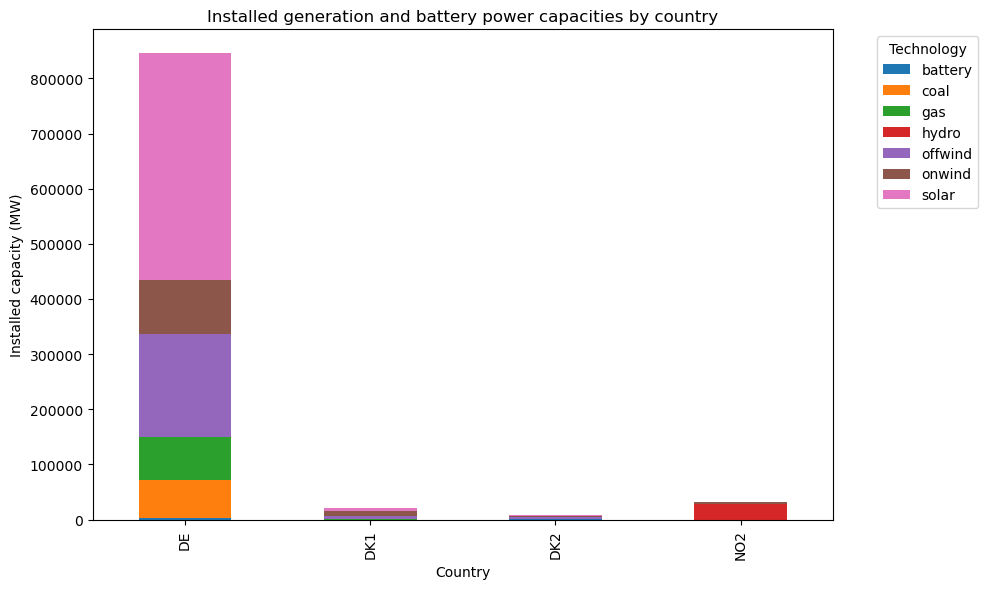

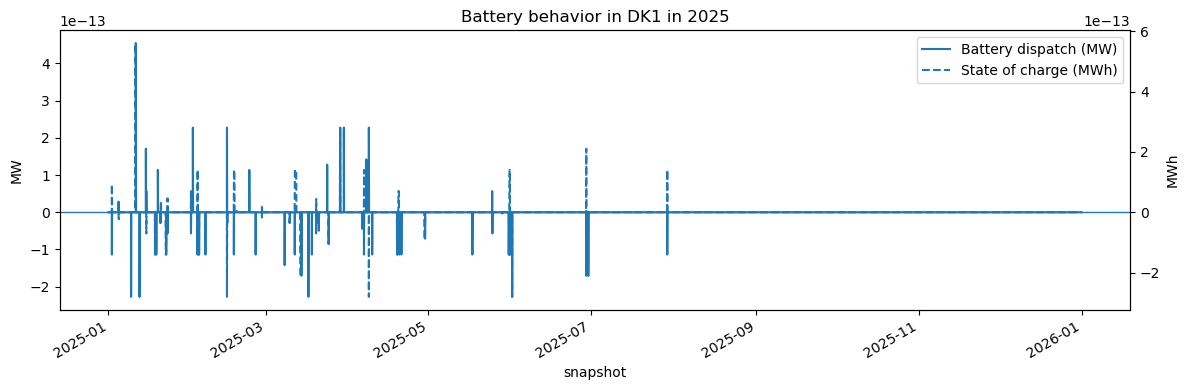

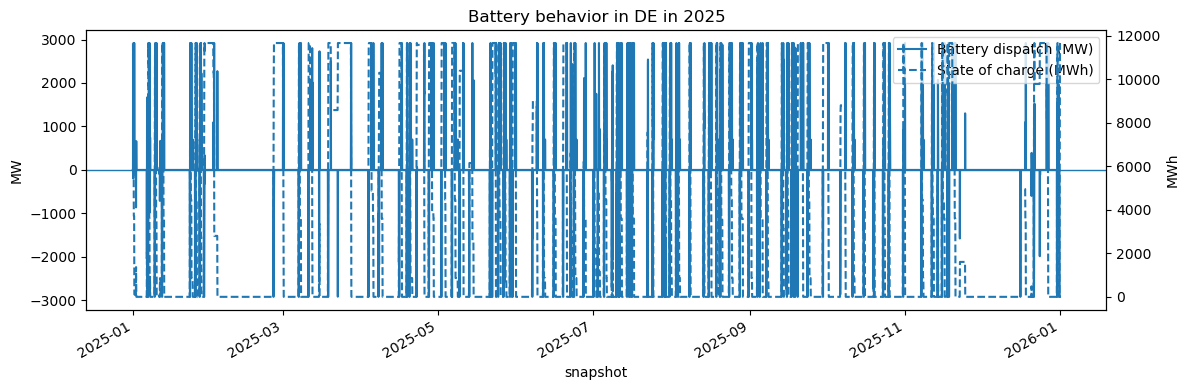

In [73]:
# -------------------------------------------------------------
# BATTERY RESULTS
# -------------------------------------------------------------
print("\n--- Battery capacities ---")
print(multi_n.storage_units[["bus", "carrier", "p_nom", "p_nom_opt", "max_hours"]])

battery_power = multi_n.storage_units["p_nom_opt"]
battery_energy = battery_power * multi_n.storage_units["max_hours"]

battery_summary = pd.DataFrame({
    "Power capacity [MW]": battery_power,
    "Energy capacity [MWh]": battery_energy
})

print("\n--- Battery power and energy capacity ---")
print(battery_summary)


# -------------------------------------------------------------
# PLOT GENERATION + BATTERY CAPACITIES
# -------------------------------------------------------------
gen_capacity = multi_n.generators.copy()
gen_capacity["capacity_MW"] = gen_capacity["p_nom_opt"].clip(lower=0)
gen_capacity["country"] = gen_capacity["bus"].str.replace("bus_", "", regex=False)

storage_capacity = multi_n.storage_units.copy()
storage_capacity["capacity_MW"] = storage_capacity["p_nom_opt"].clip(lower=0)
storage_capacity["country"] = storage_capacity["bus"].str.replace("bus_", "", regex=False)

storage_capacity = storage_capacity.rename(columns={"carrier": "carrier"})
storage_capacity["carrier"] = "battery"

capacity_combined = pd.concat([
    gen_capacity[["country", "carrier", "capacity_MW"]],
    storage_capacity[["country", "carrier", "capacity_MW"]]
])

capacity_by_country_tech = (
    capacity_combined
    .groupby(["country", "carrier"])["capacity_MW"]
    .sum()
    .unstack(fill_value=0)
)

print("\n--- Installed capacity by country and technology (MW) ---")
print(capacity_by_country_tech)

ax = capacity_by_country_tech.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Installed capacity (MW)")
plt.xlabel("Country")
plt.title("Installed generation and battery power capacities by country")
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# BATTERY BEHAVIOR IN DK1
# -------------------------------------------------------------
battery_dispatch_DK1 = multi_n.storage_units_t.p["battery_DK1"]
battery_soc_DK1 = multi_n.storage_units_t.state_of_charge["battery_DK1"]

year = slice("2025-01-01", "2025-12-31 23:00")

fig, ax1 = plt.subplots(figsize=(12, 4))

battery_dispatch_DK1.loc[year].plot(
    ax=ax1,
    label="Battery dispatch (MW)"
)

ax1.axhline(0, linewidth=1)
ax1.set_ylabel("MW")

ax2 = ax1.twinx()

battery_soc_DK1.loc[year].plot(
    ax=ax2,
    linestyle="--",
    label="State of charge (MWh)"
)

ax2.set_ylabel("MWh")

plt.title("Battery behavior in DK1 in 2025")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.show()

# -------------------------------------------------------------
# BATTERY BEHAVIOR IN DE
# -------------------------------------------------------------
battery_dispatch_DE = multi_n.storage_units_t.p["battery_DE"]
battery_soc_DE = multi_n.storage_units_t.state_of_charge["battery_DE"]

year = slice("2025-01-01", "2025-12-31 23:00")

fig, ax1 = plt.subplots(figsize=(12, 4))

battery_dispatch_DE.loc[year].plot(
    ax=ax1,
    label="Battery dispatch (MW)"
)

ax1.axhline(0, linewidth=1)
ax1.set_ylabel("MW")

ax2 = ax1.twinx()

battery_soc_DE.loc[year].plot(
    ax=ax2,
    linestyle="--",
    label="State of charge (MWh)"
)

ax2.set_ylabel("MWh")

plt.title("Battery behavior in DE in 2025")

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2)

plt.tight_layout()
plt.show()


--- Installed capacity by country and technology (MW) ---
carrier      coal           gas         hydro       offwind         onwind  \
country                                                                      
DE       68495.07  73200.649897      0.000000  21403.417000  478927.982113   
DK1          0.00    546.248000      0.000000   6300.590000    8054.401000   
DK2          0.00   1664.238094      0.000000   3109.448000    1268.901000   
NO2          0.00     59.510000  27820.762183     16.298555    3994.064697   

carrier          solar  
country                 
DE       296524.415692  
DK1        5470.770020  
DK2        1997.691430  
NO2           0.000000  


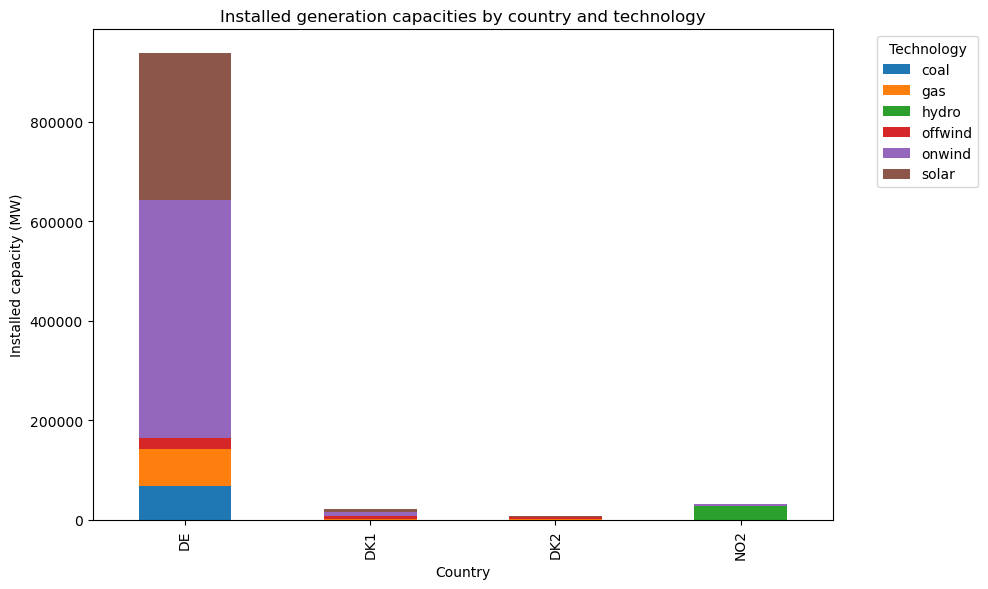

In [65]:
# -------------------------------------------------------------
# PLOT INSTALLED CAPACITIES
# -------------------------------------------------------------
capacity_plot = multi_n.generators.copy()

# Use optimized capacity
capacity_plot["capacity_MW"] = capacity_plot["p_nom_opt"].clip(lower=0)

# Extract country from bus name
capacity_plot["country"] = capacity_plot["bus"].str.replace("bus_", "", regex=False)

# Group by country and technology
capacity_by_country_tech = (
    capacity_plot
    .groupby(["country", "carrier"])["capacity_MW"]
    .sum()
    .unstack(fill_value=0)
)

print("\n--- Installed capacity by country and technology (MW) ---")
print(capacity_by_country_tech)

# Plot
ax = capacity_by_country_tech.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.ylabel("Installed capacity (MW)")
plt.xlabel("Country")
plt.title("Installed generation capacities by country and technology")
plt.legend(title="Technology", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [66]:

print("\n--- Installed Capacities (p_nom + p_nom_opt) ---")
print(multi_n.generators[["bus", "carrier", "p_nom", "p_nom_opt"]])
print(multi_n.storage_units[["bus", "carrier", "p_nom", "p_nom_opt"]])

print("\n--- Line capacities (s_nom) ---")
print(multi_n.lines[["bus0", "bus1", "x", "s_nom"]])

# -------------------------------------------------------------
# DISPATCH RESULTS
# -------------------------------------------------------------
print("\n--- Dispatch Time Series (first 5 hours) ---")
print(multi_n.generators_t.p.head())

print("\n--- Total generation per technology (MWh/year) ---")
gen_by_carrier = multi_n.generators_t.p.sum().groupby(multi_n.generators.carrier).sum()
print(gen_by_carrier)

print("\n--- Total generation per country (MWh/year) ---")
gen_by_country = multi_n.generators_t.p.sum().groupby(multi_n.generators.bus).sum()
print(gen_by_country)

# -------------------------------------------------------------
# LINE FLOWS
# -------------------------------------------------------------
print("\n--- Line flows p0 (first 5 hours) ---")
print(multi_n.lines_t.p0.head())

print("\n--- Max line loading as % of rating ---")
line_loading = multi_n.lines_t.p0.abs().max() / multi_n.lines.s_nom * 100
print(line_loading)

# -------------------------------------------------------------
# PRICES (LMPs)
# -------------------------------------------------------------
print("\n--- Marginal prices (first 5 hours) ---")
print(multi_n.buses_t.marginal_price.head())

print("\n--- Average annual electricity price per country ---")
avg_price = multi_n.buses_t.marginal_price.mean()
print(avg_price)

# -------------------------------------------------------------
# NODE BALANCE (generation - demand)
# Using TRANSPOSE instead of axis= to avoid pandas ≥2.2 error
# -------------------------------------------------------------
print("\n--- Net injection per country, first 5 hours ---")

# GENERATION grouped by country
gen_by_country_ts = (
    multi_n.generators_t.p.T               # shape: generators × time
    .groupby(multi_n.generators.bus)       # group along generator bus assignment
    .sum()                            # result: country × time
)


--- Installed Capacities (p_nom + p_nom_opt) ---
                   bus  carrier          p_nom      p_nom_opt
name                                                         
wind_on_DK1    bus_DK1   onwind    8054.401000    8054.401000
wind_off_DK1   bus_DK1  offwind    6300.590000    6300.590000
solar_DK1      bus_DK1    solar    5470.770020    5470.770020
gas_DK1        bus_DK1      gas     546.248000     546.248000
wind_on_DK2    bus_DK2   onwind    1268.901000    1268.901000
wind_off_DK2   bus_DK2  offwind    3109.448000    3109.448000
solar_DK2      bus_DK2    solar    1997.691430    1997.691430
gas_DK2        bus_DK2      gas     229.480000    1664.238094
wind_on_NO2    bus_NO2   onwind    3994.064697    3994.064697
wind_off_NO2   bus_NO2  offwind      16.298555      16.298555
solar_NO2      bus_NO2    solar       0.000000      -0.000000
gas_NO2        bus_NO2      gas      59.510000      59.510000
hydro_res_NO2  bus_NO2    hydro   27820.762183   27820.762183
wind_on_DE      bus_